In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go

In [2]:
SteamData = pd.read_csv('./csv/steam.csv')
SteamData.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
SteamData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [4]:
SteamData.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [5]:
# 1. Generamos los dummies (Igual que lo tienes)
genres_dummies = SteamData['genres'].str.get_dummies(sep=';')
categories_dummies = SteamData['categories'].str.get_dummies(sep=';')
tags_dummies = SteamData['steamspy_tags'].str.get_dummies(sep=';')

# 2. Concatenamos
SteamDataCompleto = pd.concat([SteamData, genres_dummies, categories_dummies, tags_dummies], axis=1)

# --- NUEVO PASO DE LIMPIEZA ---
# Eliminamos filas donde el nombre del juego esté repetido
SteamDataCompleto = SteamDataCompleto.drop_duplicates(subset=['name'], keep='first')
# ------------------------------

# 3. Definimos las columnas que NO queremos para el modelo
# Hemos añadido ratings, precio y playtime para que el cluster sea por género/estilo
columnas_sobrantes = [
    'appid', 'release_date', 'english', 'developer', 'publisher', 
    'platforms', 'required_age', 'achievements', 'median_playtime', 
    'owners', 'genres', 'categories', 'steamspy_tags',
    'positive_ratings', 'negative_ratings', 'average_playtime', 'price' 
]

# 4. Drop columnas
SteamDataFinal = SteamDataCompleto.drop(columnas_sobrantes, axis=1)

# 5. Set Index (Ahora será seguro porque no hay nombres repetidos)
SteamDataFinal.set_index('name', inplace=True)

print(f"Forma final del dataset: {SteamDataFinal.shape}")
print("Columnas restantes:", SteamDataFinal.columns.tolist()[:10], "... y muchas más")
SteamDataFinal.head()

Forma final del dataset: (27033, 397)
Columnas restantes: ['Accounting', 'Action', 'Adventure', 'Animation & Modeling', 'Audio Production', 'Casual', 'Design & Illustration', 'Documentary', 'Early Access', 'Education'] ... y muchas más


,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,Education,...,Warhammer 40K,Web Publishing,Werewolves,Western,Word Game,World War I,World War II,Wrestling,Zombies,e-sports
name,,,,,,,,,,,,,,,,,,,,,
Counter-Strike,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Team Fortress Classic,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Day of Defeat,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Deathmatch Classic,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Half-Life: Opposing Force,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:

scaler = StandardScaler()

data_scaled = scaler.fit_transform(SteamDataFinal)

pca = PCA(n_components=300)
data_pca = pca.fit_transform(data_scaled)

print(f"Varianza explicada total: {pca.explained_variance_ratio_.sum()}")

Varianza explicada total: 0.8736564653940377


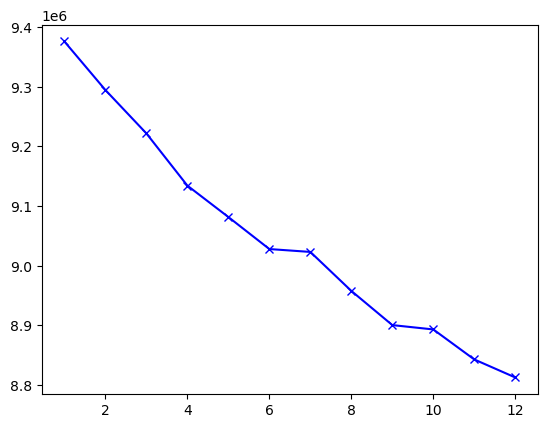

In [7]:
inertias = []
rango_k = range(1, 13) 

for i in rango_k:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)

    kmeans.fit(data_pca)
    
    inertias.append(kmeans.inertia_)
    
plt.plot(rango_k, inertias, 'bx-')

In [8]:

pipeline_clustering = make_pipeline(
    StandardScaler(),
    PCA(n_components=300),
    KMeans(n_clusters=150, random_state=42)
)

pipeline_clustering.fit(SteamDataFinal)

clusters = pipeline_clustering.named_steps['kmeans'].labels_


In [9]:

SteamDataFinal['cluster'] = clusters

print(SteamDataFinal[SteamDataFinal['cluster'] == 0].mean().sort_values(ascending=False).head(10))

Racing                0.998632
Racing                0.965800
Single-player         0.958960
Indie                 0.601915
Steam Achievements    0.502052
Indie                 0.476060
Action                0.437756
Action                0.372093
Multi-player          0.358413
Sports                0.357045
dtype: float64


In [10]:
# Cambia el 3 por cualquier número de cluster que hayas obtenido (0 al 7)
juegos_del_grupo = SteamDataFinal[SteamDataFinal['cluster'] == 0].index
print(SteamDataFinal['cluster'].value_counts())

cluster
40     5280
8      4416
7      2599
1      1986
146    1981
       ... 
121       1
123       1
118       1
54        1
2         1
Name: count, Length: 150, dtype: int64


In [11]:
# Cambia el 21 por cualquier cluster que te de curiosidad
print(SteamDataFinal[SteamDataFinal['cluster'] == 0].index[:20])

Index(['Xpand Rally', 'RACE - The WTCC Game', 'RACE: Caterham Expansion',
       'Ducati World Championship', 'Death Track®: Resurrection', 'RACE 07',
       'GTR 2 FIA GT Racing Game', 'TrackMania Nations Forever',
       'Gumboy Tournament', '18 Wheels of Steel: American Long Haul',
       'Sprint Cars Road to Knoxville', 'Midnight Outlaw: 6 Hours to SunUp',
       'Trials 2: Second Edition', 'Monster Trucks Nitro ',
       'Need for Speed Undercover', 'Zero Gear', 'Pyroblazer®',
       'Driver® Parallel Lines', 'Burnout Paradise: The Ultimate Box',
       'Need for Speed: Shift'],
      dtype='object', name='name')


In [12]:

# 1. Entrenamos un buscador de "vecinos"
# Usamos los datos del PCA que ya tienes listos
buscador = NearestNeighbors(n_neighbors=6, metric='euclidean')
buscador.fit(data_pca)

# 2. Función para recomendar
def recomendar(nombre_juego):
    # Buscamos la posición (índice) del juego
    idx = SteamDataFinal.index.get_loc(nombre_juego)
    
    # El buscador nos da las distancias y los índices de los 6 más cercanos
    # (El primero siempre será el mismo juego, por eso pedimos 6 para dar 5)
    distancias, indices = buscador.kneighbors([data_pca[idx]])
    
    # Mostramos los nombres
    return SteamDataFinal.index[indices[0][1:]]

# Uso:
print(recomendar('Half-Life 2'))

Index(['Half-Life 2: Episode One', 'Half-Life 2: Episode Two',
       'Sol Galaxy Defender', 'A Day For A Kitten', 'The Forgotten Ones'],
      dtype='object', name='name')


In [13]:

# 1. Primero, eliminamos duplicados en el índice para evitar el error
# Esto mantiene solo la primera aparición de cada juego
SteamDataFinal = SteamDataFinal[~SteamDataFinal.index.duplicated(keep='first')]

# 2. Ahora sí, ejecutamos el PCA 3D
pca_3d = PCA(n_components=3)
data_3d = pca_3d.fit_transform(data_scaled) # Asegúrate que data_scaled tenga el mismo número de filas que SteamDataFinal ahora

# 3. Creamos el DataFrame de visualización
df_visualizacion = pd.DataFrame(data=data_3d, columns=['PC1', 'PC2', 'PC3'])

# OJO AQUÍ: Como reseteamos SteamDataFinal, lo mejor es usar .values 
# para que no intente comparar los índices de nuevo
df_visualizacion['Juego'] = SteamDataFinal.index
df_visualizacion['Cluster'] = SteamDataFinal['cluster'].values # .values evita el error de reindexación

# 4. Y ahora el gráfico (el resto del código de 'go' igual que antes)

# 3. Creamos la figura con Graph Objects
fig = go.Figure(data=[go.Scatter3d(
    x=df_visualizacion['PC1'],
    y=df_visualizacion['PC2'],
    z=df_visualizacion['PC3'],
    mode='markers',
    marker=dict(
        size=2,                  # Puntos pequeños para que no se amontonen (son 27k juegos)
        color=df_visualizacion['Cluster'], # El color varía según el cluster
        colorscale='Viridis',    # Una escala de colores profesional
        opacity=0.6              # Un poco de transparencia para ver la densidad
    ),
    text=df_visualizacion['Juego'], # El nombre que aparecerá al pasar el cursor
    hoverinfo='text'
)])

# 4. Personalización del diseño (Layout)
fig.update_layout(
    title='Visualización 3D de Clusters de Videojuegos',
    scene=dict(
        xaxis=dict(title='PC 1 (Estilo)'),
        yaxis=dict(title='PC 2 (Mecánicas)'),
        zaxis=dict(title='PC 3 (Popularidad/Otros)')
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Aprovechar todo el espacio
)

# 5. Mostrar
fig.show()

In [14]:
import joblib

# 1. Guardamos el pipeline completo (Escalador + PCA + K-Means)
joblib.dump(pipeline_clustering, 'pipeline_steam.joblib')

# 2. Guardamos el buscador (NearestNeighbors)
joblib.dump(buscador, 'modelo_recomendador.joblib')

# 3. Guardamos el DataFrame final con los clusters asignados
# Lo guardamos en formato .pkl (pickle) porque mantiene los índices y tipos de datos mejor que un CSV
SteamDataFinal.to_pickle('datos_steam_con_clusters.pkl')

print("¡Todo guardado con éxito! Tienes los archivos listos para la App.")

¡Todo guardado con éxito! Tienes los archivos listos para la App.
